In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.4 MB/s eta 0:00:00


In [2]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models
import torch.nn as nn
from ultralytics import YOLO
from PIL import Image
from google.colab import files
from torchvision import datasets, transforms


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# Load and prepare models

# detection model
det_model = YOLO(
    "/content/drive/MyDrive/Smart_Vision/yolo_runs/yolov8m_detection/weights/best.pt"
)

# classification model
clf_model = models.resnet50(pretrained=False)

NUM_CLASSES = 26

clf_model.fc = nn.Sequential(
    nn.Linear(clf_model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

# apply weights
clf_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Smart_Vision/resnet50_best.pth",
        map_location=device
    )
)

clf_model.eval()
clf_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
# Detection Predictions

uploaded = files.upload()

results = det_model.predict(
    source=list(uploaded.keys())[0],
    half=True,
    conf=0.5,
    iou=0.4,
    max_det=10
)

Saving image_000058.jpg to image_000058.jpg

image 1/1 /content/image_000058.jpg: 832x960 2 persons, 355473.5ms
Speed: 10.8ms preprocess, 355473.5ms inference, 45.6ms postprocess per image at shape (1, 3, 832, 960)


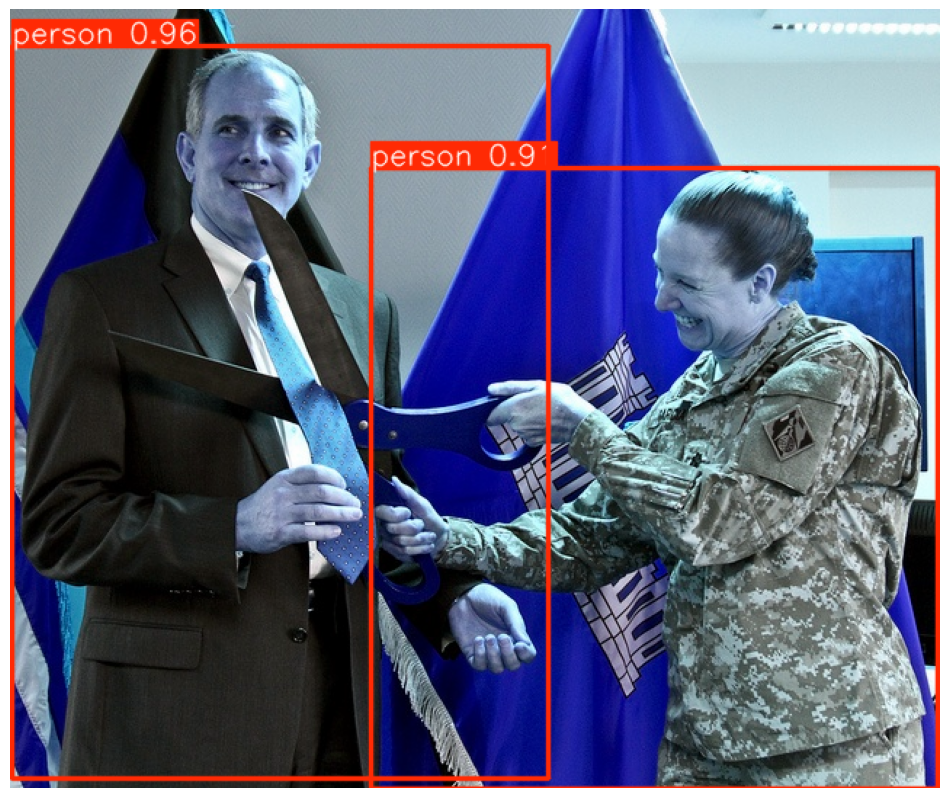

In [8]:
# Visualization
result_img = results[0].plot()

plt.figure(figsize=(12,12))
plt.imshow(result_img)
plt.axis("off")
plt.show()

# Classification

In [9]:
# Define Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
TRAIN_PATH = "/content/drive/MyDrive/Smart_Vision/classification/train"

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Number of Classes:", len(class_names))

Classes: ['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']
Number of Classes: 26


In [10]:
# transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# load image
img_path = "/content/drive/MyDrive/Smart_Vision/classification/test/cat/cat_test_0003.jpg"
# img_path = "/content/Screenshot 2026-05-17 154355.png"
image = Image.open(img_path).convert("RGB")
# image = files.upload()
# preprocess
image = transform(image)

# add batch dimension
image = image.unsqueeze(0).to(device)

# prediction
with torch.no_grad():
    outputs = clf_model(image)

predicted = torch.argmax(outputs, dim=1)

print("Prediction:", class_names[predicted.item()])

Prediction: cat


In [11]:
# ============================================================
# PERFORMANCE OPTIMIZATION
# ============================================================

# ------------------------------------------------------------
# 1. DEVICE CONFIGURATION (GPU ACCELERATION)
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# ------------------------------------------------------------
# 2. LOAD YOLO MODEL
# ------------------------------------------------------------

det_model = YOLO(
    "/content/drive/MyDrive/Smart_Vision/yolo_runs/yolov8m_detection/weights/best.pt"
)

# ------------------------------------------------------------
# 3. HALF PRECISION INFERENCE (MEMORY + SPEED OPTIMIZATION)
# ------------------------------------------------------------

# FP16 inference reduces memory usage and improves speed
# Works only on GPU

use_half = torch.cuda.is_available()

# ------------------------------------------------------------
# 4. BATCH PROCESSING
# ------------------------------------------------------------

# Predict on multiple images together
# Improves throughput

results = det_model.predict(

    source="/content/drive/MyDrive/Smart_Vision/detection/images",    # folder of images

    batch=8,                                                          # batch inference

    imgsz=640,

    conf=0.5,

    iou=0.4,

    device=0 if torch.cuda.is_available() else "cpu",

    half=use_half,

    stream=False,

    verbose=True
)

# ------------------------------------------------------------
# 5. MODEL EXPORT (DEPLOYMENT OPTIMIZATION)
# ------------------------------------------------------------

# Export optimized TorchScript model

det_model.export(format="torchscript")

print("TorchScript model exported successfully!")

# ------------------------------------------------------------
# 6. OPTIONAL DYNAMIC QUANTIZATION (CLASSIFICATION MODEL)
# ------------------------------------------------------------

# CNN classification model optimization

resnet50_quantized = torch.quantization.quantize_dynamic(
    clf_model,
    {torch.nn.Linear},
    dtype=torch.qint8
)

print("Classification model quantized successfully!")

# ============================================================
# SAVE QUANTIZED MODEL
# ============================================================

SAVE_PATH = "/content/drive/MyDrive/Smart_Vision/resnet50_quantized.pth"

torch.save(
    resnet50_quantized.state_dict(),
    SAVE_PATH
)

print(f"✅ Quantized model saved at:\n{SAVE_PATH}")
# ============================================================
# END OF PERFORMANCE OPTIMIZATION
# ============================================================

Using Device: cpu

image 1/2210 /content/drive/MyDrive/Smart_Vision/detection/images/image_000000.jpg: 640x640 1 person, 2404.1ms
image 2/2210 /content/drive/MyDrive/Smart_Vision/detection/images/image_000001.jpg: 640x640 1 person, 1 horse, 2404.1ms
image 3/2210 /content/drive/MyDrive/Smart_Vision/detection/images/image_000002.jpg: 640x640 1 person, 1 horse, 2404.1ms
image 4/2210 /content/drive/MyDrive/Smart_Vision/detection/images/image_000003.jpg: 640x640 1 person, 1 horse, 2404.1ms
image 5/2210 /content/drive/MyDrive/Smart_Vision/detection/images/image_000004.jpg: 640x640 1 person, 1 horse, 2404.1ms
image 6/2210 /content/drive/MyDrive/Smart_Vision/detection/images/image_000005.jpg: 640x640 1 person, 1 horse, 2404.1ms
image 7/2210 /content/drive/MyDrive/Smart_Vision/detection/images/image_000006.jpg: 640x640 1 person, 1 horse, 2404.1ms
image 8/2210 /content/drive/MyDrive/Smart_Vision/detection/images/image_000007.jpg: 640x640 1 person, 1 elephant, 2404.1ms
image 9/2210 /content/drive

/tmp/ipykernel_1671/1551635676.py:74: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  resnet50_quantized = torch.quantization.quantize_dynamic(


✅ Quantized model saved at:
/content/drive/MyDrive/Smart_Vision/resnet50_quantized.pth
